In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

In [3]:
file_path = "Eight_Databases.xlsx"

xls = pd.ExcelFile(file_path)

print(xls.sheet_names)

['12-Year Gasoline', 'Agricultural', 'Consumer Food', 'Energy', 'Financial', 'International Labor', 'Manufacturer', 'Sheet1', 'U.S. International Stock Market']


In [5]:
df_fin = pd.read_excel(xls, sheet_name='Financial')
df_fin.head()

,Company,Type,Total Revenues,Total Assets,Return on Equity,Earnings per Share,Average Yield,Dividends per Share,Average P/E Ratio
0,AFLAC,6,7251,29454,17.1,2.08,0.9,0.22,11.5
1,Albertson's,4,14690,5219,21.4,2.08,1.6,0.63,19.0
2,Allstate,6,20106,80918,20.1,3.56,1.0,0.36,10.6
3,Amerada Hess,7,8340,7935,0.2,0.08,1.1,0.60,698.3
4,American General,6,3362,80620,7.1,2.19,3.0,1.40,21.2


In [7]:
df_fin.describe()
df_fin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Company              100 non-null    object 
 1   Type                 100 non-null    int64  
 2   Total Revenues       100 non-null    int64  
 3   Total Assets         100 non-null    int64  
 4   Return on Equity     100 non-null    float64
 5   Earnings per Share   100 non-null    float64
 6   Average Yield        100 non-null    float64
 7   Dividends per Share  100 non-null    float64
 8   Average P/E Ratio    100 non-null    float64
dtypes: float64(5), int64(3), object(1)
memory usage: 7.2+ KB


In [15]:
df_fin.columns

Index(['Company', 'Type', 'Total Revenues', 'Total Assets', 'Return on Equity',
       'Earnings per Share', 'Average Yield', 'Dividends per Share',
       'Average P/E Ratio'],
      dtype='object')

In [19]:
df_fin.columns = df_fin.columns.str.strip().str.lower().str.replace(" ", "_")
df_fin.head()

,company,type,total_revenues,total_assets,return_on_equity,earnings_per_share,average_yield,dividends_per_share,average_p/e_ratio
0,AFLAC,6,7251,29454,17.1,2.08,0.9,0.22,11.5
1,Albertson's,4,14690,5219,21.4,2.08,1.6,0.63,19.0
2,Allstate,6,20106,80918,20.1,3.56,1.0,0.36,10.6
3,Amerada Hess,7,8340,7935,0.2,0.08,1.1,0.60,698.3
4,American General,6,3362,80620,7.1,2.19,3.0,1.40,21.2


In [23]:
df_fin.sort_values('total_revenues', ascending=False).head()

,company,type,total_revenues,total_assets,return_on_equity,earnings_per_share,average_yield,dividends_per_share,average_p/e_ratio
30,Exxon,7,137242,96064,19.4,3.37,2.8,1.63,17.1
54,Mobil,7,65906,43559,16.8,4.01,3.1,2.12,17.2
82,Texaco,7,46667,29600,20.9,4.87,3.1,1.75,11.5
23,E. I. DuPont DeNemours,2,46653,42942,21.3,2.08,2.1,1.23,27.9
15,Chevron,7,41950,35473,18.6,4.95,3.0,2.28,15.2


In [25]:
df_fin.sort_values('return_on_equity', ascending=False).head()

,company,type,total_revenues,total_assets,return_on_equity,earnings_per_share,average_yield,dividends_per_share,average_p/e_ratio
33,Georgia Gulf,2,966,613,228.0,2.39,1.1,0.32,11.8
29,Ethyl,7,1064,1067,53.6,0.71,5.6,0.50,12.6
77,Schering-Plough,5,6778,6507,51.2,1.95,1.5,0.74,24.6
39,Hercules,2,1866,2411,47.0,3.18,2.2,1.00,14.5
47,Lyondell Petrochemical,7,3010,1559,46.2,3.58,3.9,0.90,6.4


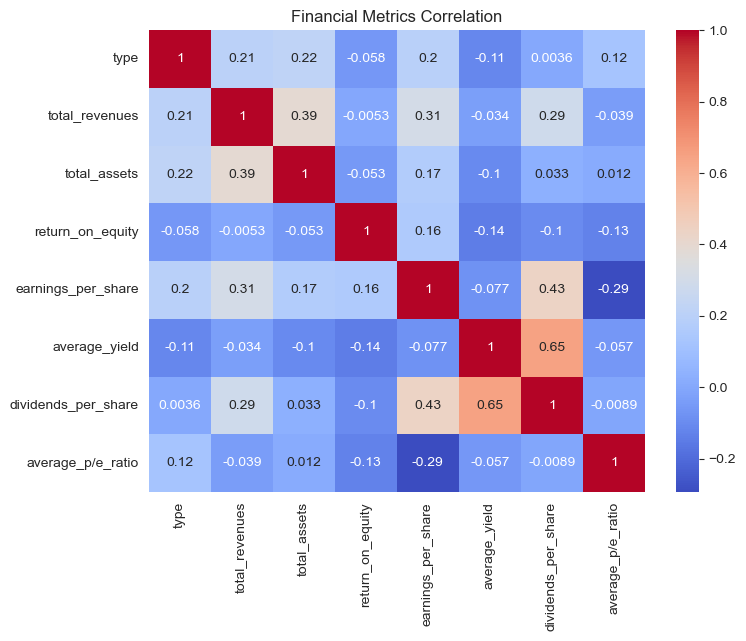

In [27]:
corr = df_fin.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Financial Metrics Correlation")
plt.show()

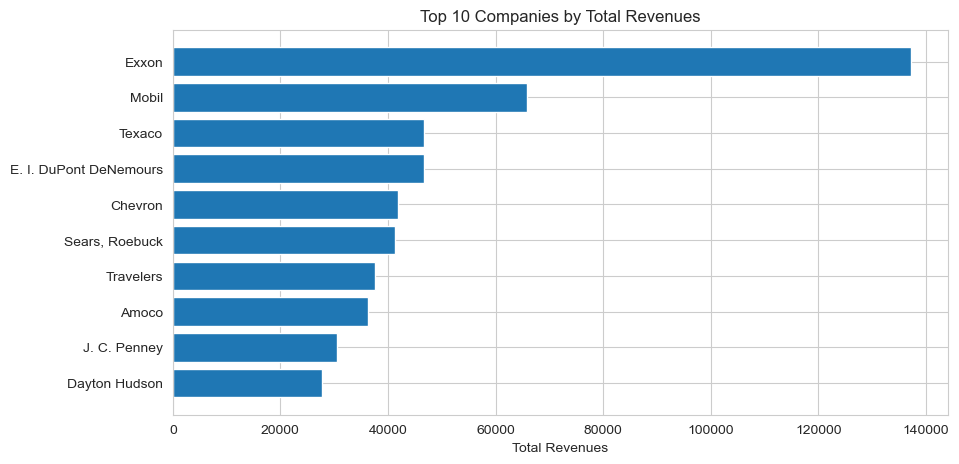

In [32]:
top_rev = df_fin.sort_values('total_revenues', ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.barh(top_rev['company'], top_rev['total_revenues'])
plt.title("Top 10 Companies by Total Revenues")
plt.xlabel("Total Revenues")
plt.gca().invert_yaxis()
plt.show()

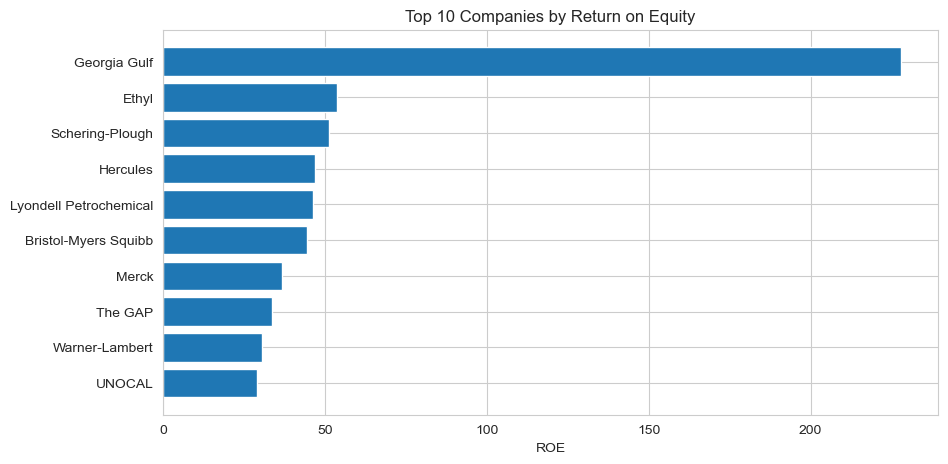

In [34]:
top_roe = df_fin.sort_values('return_on_equity', ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.barh(top_roe['company'], top_roe['return_on_equity'])
plt.title("Top 10 Companies by Return on Equity")
plt.xlabel("ROE")
plt.gca().invert_yaxis()
plt.show()

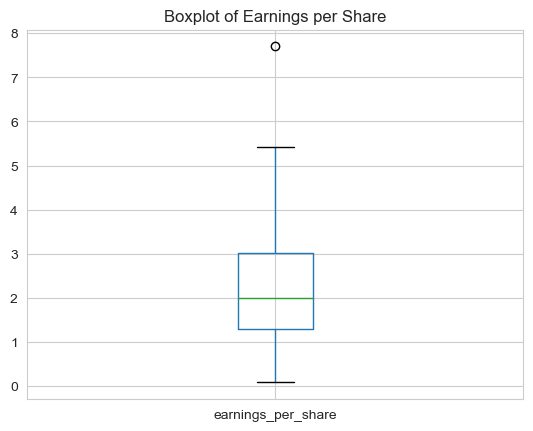

In [38]:
plt.figure()
df_fin.boxplot(column='earnings_per_share')
plt.title("Boxplot of Earnings per Share")
plt.show()

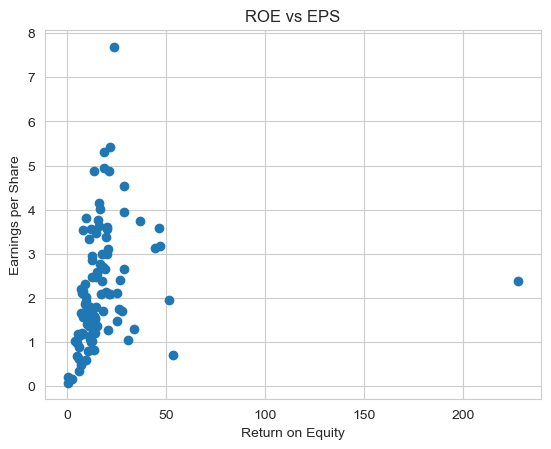

In [40]:
plt.figure()
plt.scatter(df_fin['return_on_equity'], df_fin['earnings_per_share'])
plt.xlabel("Return on Equity")
plt.ylabel("Earnings per Share")
plt.title("ROE vs EPS")
plt.show()

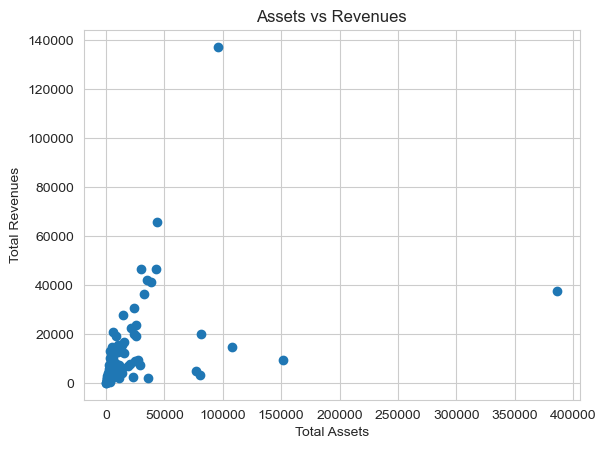

In [42]:
plt.figure()
plt.scatter(df_fin['total_assets'], df_fin['total_revenues'])
plt.xlabel("Total Assets")
plt.ylabel("Total Revenues")
plt.title("Assets vs Revenues")
plt.show()

Traceback (most recent call last):
  File "<frozen runpy>", line 189, in _run_module_as_main
  File "<frozen runpy>", line 148, in _get_module_details
  File "<frozen runpy>", line 112, in _get_module_details
  File "C:\Users\ICT\.anaconda\Lib\site-packages\nbconvert\__init__.py", line 5, in <module>
    from .exporters import *
  File "C:\Users\ICT\.anaconda\Lib\site-packages\nbconvert\exporters\__init__.py", line 1, in <module>
    from .asciidoc import ASCIIDocExporter
  File "C:\Users\ICT\.anaconda\Lib\site-packages\nbconvert\exporters\asciidoc.py", line 9, in <module>
    from .templateexporter import TemplateExporter
  File "C:\Users\ICT\.anaconda\Lib\site-packages\nbconvert\exporters\templateexporter.py", line 25, in <module>
    from lxml.html.clean import clean_html
  File "C:\Users\ICT\.anaconda\Lib\site-packages\lxml\html\clean.py", line 18, in <module>
    raise ImportError(
ImportError: lxml.html.clean module is now a separate project lxml_html_clean.
Install lxml[html_cle